# Finding How the Data Is Distributed

This is my own practice notebook based on what I learned in the IBM Data Analyst Capstone Project on Coursera.

## Goal

Practise checking how values are distributed across a survey dataset using counts, charts, language comparisons, correlation, crosstab analysis, and CSV export.

## Workflow rule

- `df` = original loaded dataset
- `df_cleaned` = cleaned working dataset
- `corr_df` = separate dataframe only for correlation analysis


## Step 1: Import libraries and load data


In [12]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Load the dataset
data_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(data_url)

# Preview the first rows
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


## Step 2: Examine the structure of the data


In [13]:
# Show column names
print(df.columns)

# Show data types
print(df.dtypes)

# Show dataframe structure and non-null counts
df.info()


Index(['ResponseId', 'MainBranch', 'Age', 'Employment', 'RemoteWork', 'Check',
       'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline',
       ...
       'JobSatPoints_6', 'JobSatPoints_7', 'JobSatPoints_8', 'JobSatPoints_9',
       'JobSatPoints_10', 'JobSatPoints_11', 'SurveyLength', 'SurveyEase',
       'ConvertedCompYearly', 'JobSat'],
      dtype='object', length=114)
ResponseId               int64
MainBranch              object
Age                     object
Employment              object
RemoteWork              object
                        ...   
JobSatPoints_11        float64
SurveyLength            object
SurveyEase              object
ConvertedCompYearly    float64
JobSat                 float64
Length: 114, dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65437 entries, 0 to 65436
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), object(100)
memory usage: 56.9+ MB


## Step 3: Handle missing data


In [14]:
# Check for missing values in each column
print(df.isnull().sum())

# Create a cleaned working copy of the dataset
df_cleaned = df.copy()

# Fill selected missing values with clear labels
df_cleaned['RemoteWork'] = df_cleaned['RemoteWork'].fillna('Unknown')
df_cleaned['JobSat'] = df_cleaned['JobSat'].fillna('Not answered')

# Verify missing values in the cleaned columns
print(df_cleaned[['RemoteWork', 'JobSat']].isnull().sum())


ResponseId                 0
MainBranch                 0
Age                        0
Employment                 0
RemoteWork             10631
                       ...  
JobSatPoints_11        35992
SurveyLength            9255
SurveyEase              9199
ConvertedCompYearly    42002
JobSat                 36311
Length: 114, dtype: int64
RemoteWork    0
JobSat        0
dtype: int64


## Step 4: Analyze key columns


In [15]:
# Count each Employment category
print(df_cleaned['Employment'].value_counts())

# Count each JobSat value
print(df_cleaned['JobSat'].value_counts())

# Count each YearsCodePro value
print(df_cleaned['YearsCodePro'].value_counts())


Employment
Employed, full-time                                                                                                                                   39041
Independent contractor, freelancer, or self-employed                                                                                                   4846
Student, full-time                                                                                                                                     4709
Employed, full-time;Independent contractor, freelancer, or self-employed                                                                               3557
Not employed, but looking for work                                                                                                                     2341
                                                                                                                                                      ...  
Not employed, but looking for work;Independent contra

## Step 5: Visualize Job Satisfaction


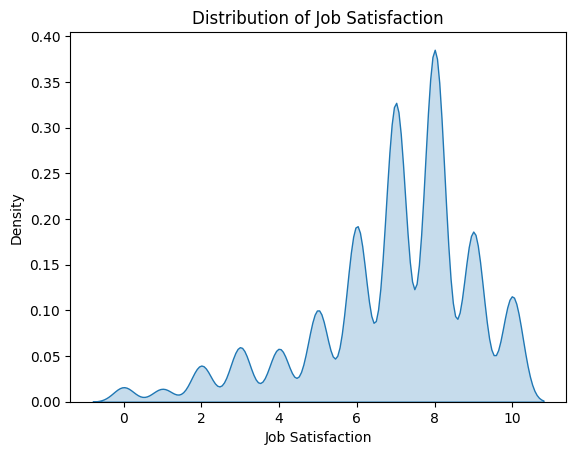

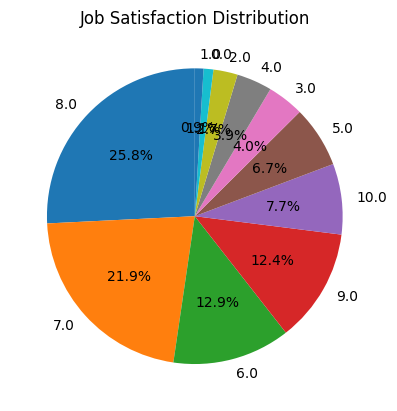

In [16]:
# Keep only real JobSat answers and convert them to numbers
job_sat = df_cleaned[df_cleaned['JobSat'] != 'Not answered']['JobSat'].astype(float)

# Create a KDE plot for JobSat distribution
sns.kdeplot(job_sat, fill=True)

plt.title('Distribution of Job Satisfaction')
plt.xlabel('Job Satisfaction')
plt.ylabel('Density')
plt.show()

# Count JobSat values, excluding "Not answered" if it exists
job_counts = df_cleaned[df_cleaned['JobSat'] != 'Not answered']['JobSat'].value_counts()

# Create a pie chart for JobSat distribution
plt.pie(job_counts, labels=job_counts.index, autopct='%1.1f%%', startangle=90)

plt.title('Job Satisfaction Distribution')
plt.show()


## Step 6: Programming Languages Analysis


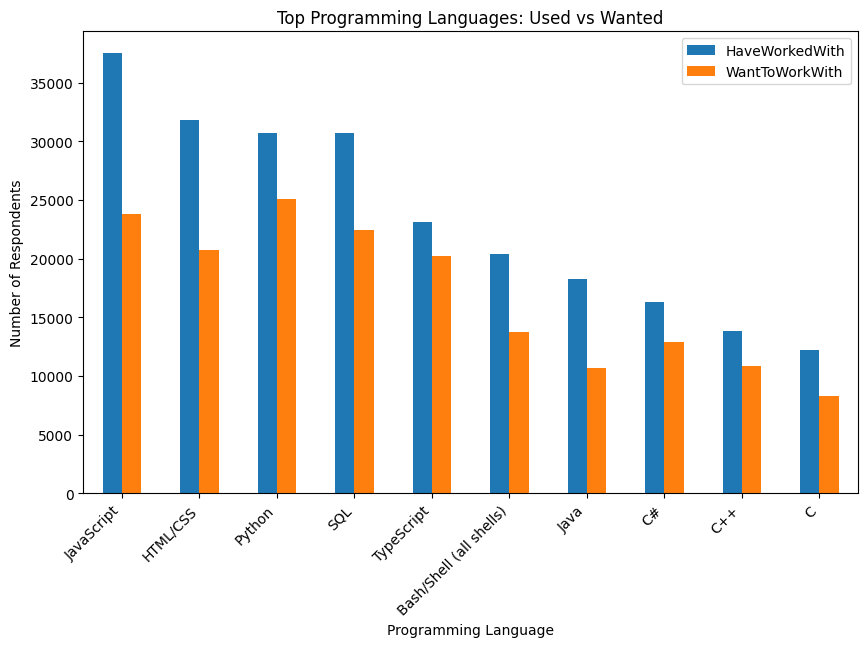

In [17]:
# Split and count languages respondents have worked with
have_langs = df_cleaned['LanguageHaveWorkedWith'].dropna().str.split(';').sum()
have_counts = Counter(have_langs)

# Split and count languages respondents want to work with
want_langs = df_cleaned['LanguageWantToWorkWith'].dropna().str.split(';').sum()
want_counts = Counter(want_langs)

# Create a dataframe to compare used vs wanted languages
df_langs = pd.DataFrame({
    'HaveWorkedWith': pd.Series(have_counts),
    'WantToWorkWith': pd.Series(want_counts)
}).fillna(0)

# Select the top 10 languages based on current usage
top_langs = df_langs.sort_values('HaveWorkedWith', ascending=False).head(10)

# Plot the top languages
top_langs.plot(kind='bar', figsize=(10, 6))

plt.title('Top Programming Languages: Used vs Wanted')
plt.xlabel('Programming Language')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45, ha='right')
plt.show()


## Step 7: Analyze Remote Work Trends


RemoteWork
Hybrid (some remote, some in-person)    23015
Remote                                  20831
In-person                               10960
Unknown                                 10631
Name: count, dtype: int64


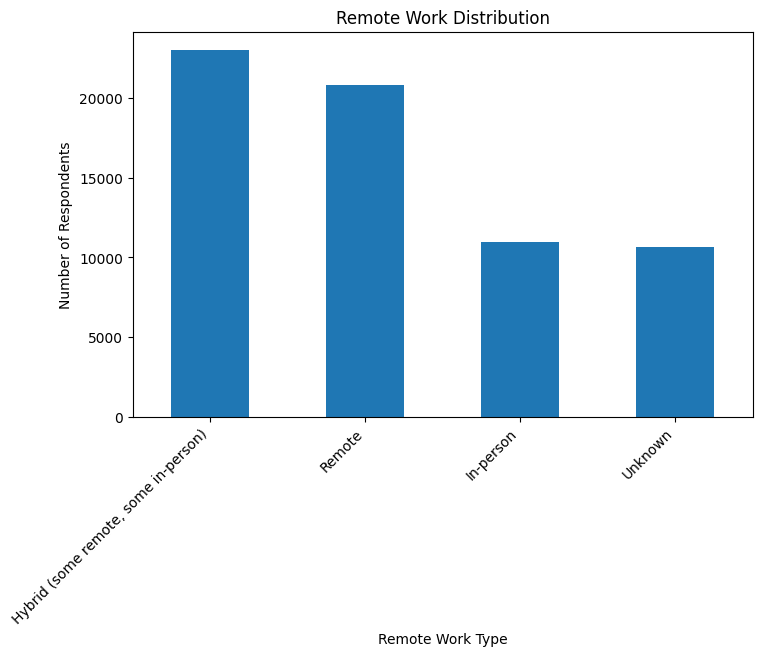

In [18]:
# Count each RemoteWork category in the cleaned dataset
remote_counts = df_cleaned['RemoteWork'].value_counts()

# Show the counts
print(remote_counts)

# Plot RemoteWork distribution
remote_counts.plot(kind='bar', figsize=(8, 5))

plt.title('Remote Work Distribution')
plt.xlabel('Remote Work Type')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45, ha='right')
plt.show()


## Step 8: Correlation between Job Satisfaction and Experience


In [19]:
# Create a separate dataframe only for correlation analysis
corr_df = df_cleaned[['JobSat', 'YearsCodePro']].copy()

# Keep only real JobSat answers
corr_df = corr_df[corr_df['JobSat'] != 'Not answered']

# Replace special text values in YearsCodePro
corr_df['YearsCodePro'] = corr_df['YearsCodePro'].replace({
    'Less than 1 year': 0,
    'More than 50 years': 51
})

# Convert JobSat and YearsCodePro to numbers
corr_df['JobSat'] = pd.to_numeric(corr_df['JobSat'], errors='coerce')
corr_df['YearsCodePro'] = pd.to_numeric(corr_df['YearsCodePro'], errors='coerce')

# Remove rows with missing JobSat or YearsCodePro
corr_df = corr_df[['JobSat', 'YearsCodePro']].dropna()

# Calculate Pearson correlation
pearson_corr = corr_df['JobSat'].corr(corr_df['YearsCodePro'], method='pearson')

print("Pearson correlation between JobSat and YearsCodePro:")
print(pearson_corr)


Pearson correlation between JobSat and YearsCodePro:
0.10415320964659903


## Step 9: Cross-tabulation Analysis: Employment vs Education Level


In [20]:
# Create a full cross-tabulation table between education level and employment type
employment_edu = pd.crosstab(
    df_cleaned['EdLevel'],
    df_cleaned['Employment']
)

# Show the full table with all employment categories
employment_edu


Employment,"Employed, full-time","Employed, full-time;Employed, part-time","Employed, full-time;Independent contractor, freelancer, or self-employed","Employed, full-time;Independent contractor, freelancer, or self-employed;Employed, part-time","Employed, full-time;Independent contractor, freelancer, or self-employed;Employed, part-time;Retired","Employed, full-time;Independent contractor, freelancer, or self-employed;Not employed, and not looking for work","Employed, full-time;Independent contractor, freelancer, or self-employed;Not employed, and not looking for work;Employed, part-time","Employed, full-time;Independent contractor, freelancer, or self-employed;Not employed, and not looking for work;Student, part-time","Employed, full-time;Independent contractor, freelancer, or self-employed;Retired","Employed, full-time;Independent contractor, freelancer, or self-employed;Student, part-time",...,"Student, full-time;Not employed, but looking for work;Not employed, and not looking for work","Student, full-time;Not employed, but looking for work;Not employed, and not looking for work;Student, part-time","Student, full-time;Not employed, but looking for work;Retired","Student, full-time;Not employed, but looking for work;Student, part-time","Student, full-time;Student, part-time","Student, full-time;Student, part-time;Employed, part-time","Student, full-time;Student, part-time;Retired","Student, part-time","Student, part-time;Employed, part-time","Student, part-time;Retired"
EdLevel,,,,,,,,,,,,,,,,,,,,,
"Associate degree (A.A., A.S., etc.)",1059,9,104,11,0,0,0,0,0,5,...,0,0,0,0,2,0,0,12,24,0
"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",16806,90,1381,79,0,0,1,0,0,49,...,0,1,0,3,12,1,0,105,184,0
"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",11011,61,963,45,0,1,0,0,0,26,...,0,0,1,0,2,1,0,26,85,2
Primary/elementary school,160,1,25,1,0,1,0,1,0,0,...,0,0,0,0,5,1,1,48,4,0
"Professional degree (JD, MD, Ph.D, Ed.D, etc.)",2073,8,159,10,1,0,0,0,0,1,...,0,0,0,0,0,0,0,5,5,0
"Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)",1460,9,181,6,0,0,1,0,0,6,...,0,0,0,2,12,0,1,140,100,0
Some college/university study without earning a degree,3579,15,492,14,0,0,0,0,1,39,...,5,0,0,4,7,4,0,75,103,1
Something else,377,3,41,2,0,0,0,0,0,4,...,0,0,0,1,5,0,0,17,14,1


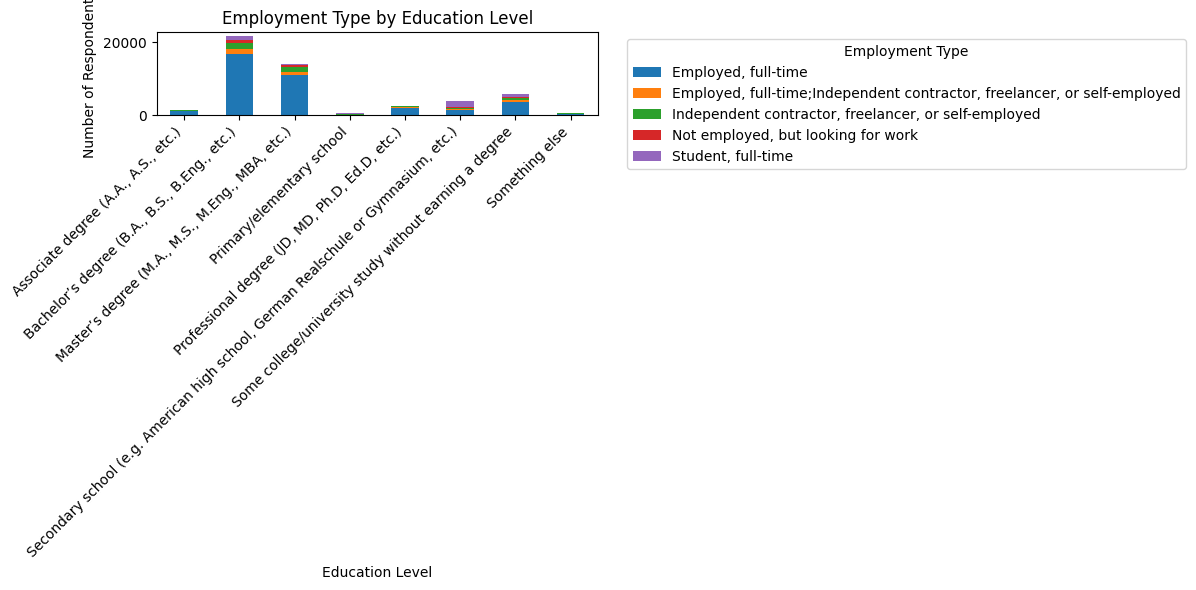

In [21]:
# Find the top 5 most common employment types
top_employment_types = df_cleaned['Employment'].value_counts().head(5).index

# Keep only rows that belong to the top 5 employment types
employment_edu_top = df_cleaned[df_cleaned['Employment'].isin(top_employment_types)]

# Create a smaller cross-tabulation table for the chart
employment_edu_chart = pd.crosstab(
    employment_edu_top['EdLevel'],
    employment_edu_top['Employment']
)

# Create a readable stacked bar chart
employment_edu_chart.plot(kind='bar', stacked=True, figsize=(12, 6))

# Add chart title and labels
plt.title('Employment Type by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Number of Respondents')

# Rotate x-axis labels so long education labels are easier to read
plt.xticks(rotation=45, ha='right')

# Move the legend outside the chart
plt.legend(title='Employment Type', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adjust layout so labels and legend fit better
plt.tight_layout()

# Show the chart
plt.show()


## Step 10: Export Cleaned Data


In [22]:
# Save the cleaned dataframe as a CSV file
df_cleaned.to_csv('cleaned_survey_data.csv', index=False)

# Confirm that the file was saved
print("Cleaned dataset saved successfully as cleaned_survey_data.csv")


Cleaned dataset saved successfully as cleaned_survey_data.csv


## Final note

This notebook keeps the workflow consistent by using `df_cleaned` after the missing-value handling step and by using `corr_df` only for correlation analysis.
